In [2]:
import pandas as pd
import numpy as np
import import_ipynb
import clean_file
import preprocessing_file
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'../data/house_price.csv')
df = clean_file.run_cleaning_pipeline(df)
X, Y = preprocessing_file.run_preprocessing_pipeline(df)

In [4]:
X.shape, Y.shape

((13262, 246), (13262,))

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.2,      
    random_state=42     
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5,      
    random_state=42     
)

In [6]:
print(X_train.shape, X_test.shape, X_val.shape)
print(y_train.shape, y_test.shape, y_val.shape)

(10609, 246) (1326, 246) (1327, 246)
(10609,) (1326,) (1327,)


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Build model
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(1)  
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# automatically reduce the learning rate when the model stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/300
332/332 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 7.2812 - mae: 2.0687 - val_loss: 0.8222 - val_mae: 0.5699 - learning_rate: 0.0010
Epoch 2/300
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.2028 - mae: 1.0962 - val_loss: 0.5677 - val_mae: 0.4254 - learning_rate: 0.0010
Epoch 3/300
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.6898 - mae: 0.9477 - val_loss: 0.5059 - val_mae: 0.3863 - learning_rate: 0.0010
Epoch 4/300
332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1.4436 - mae: 0.8683 - val_loss: 0.4821 - val_mae: 0.3747 - learning_rate: 0.0010
Epoch 5/300
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.2290 - mae: 0.7903 - val_loss: 0.5090 - val_mae: 0.4133 - learning_rate: 0.0010
Epoch 6/300
332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1.0733 - mae: 0.7271 - val_loss: 0.4207 - val_mae: 0.3399 - learning_rate: 0.0010
Epoch 7/300
332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.9872 - mae: 0.6909 - val_loss: 0.3900 - val_mae: 0.3139 - learning_rate

In [9]:
# Evaluate

from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test_scaled)

# sklearn MAE (log-space check)
mae_log_sklearn = mean_absolute_error(y_test, y_pred)
print(f"Test MAE (Sklearn, log space): {mae_log_sklearn}")


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Test MAE (Sklearn, log space): 0.21197721002371228


In [10]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 score (log space):", r2)

R2 score (log space): 0.8013120695507171


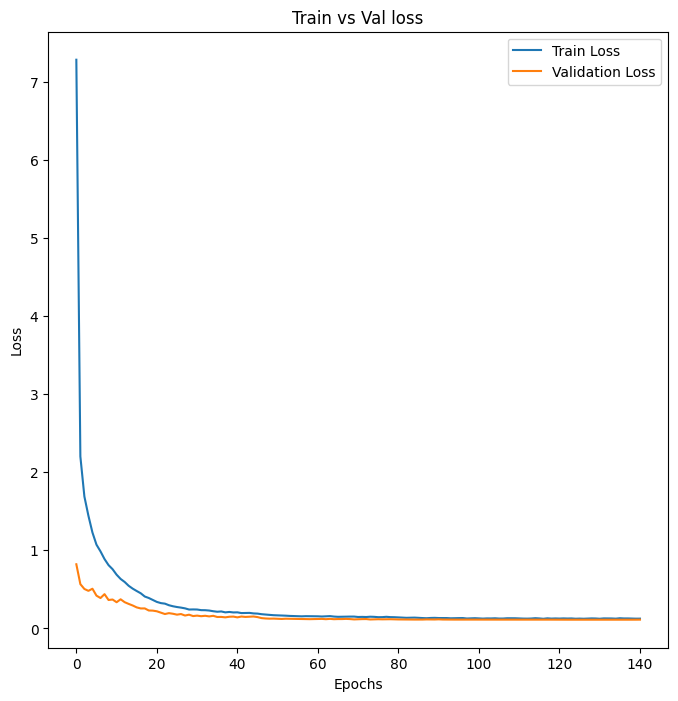

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Train vs Val loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

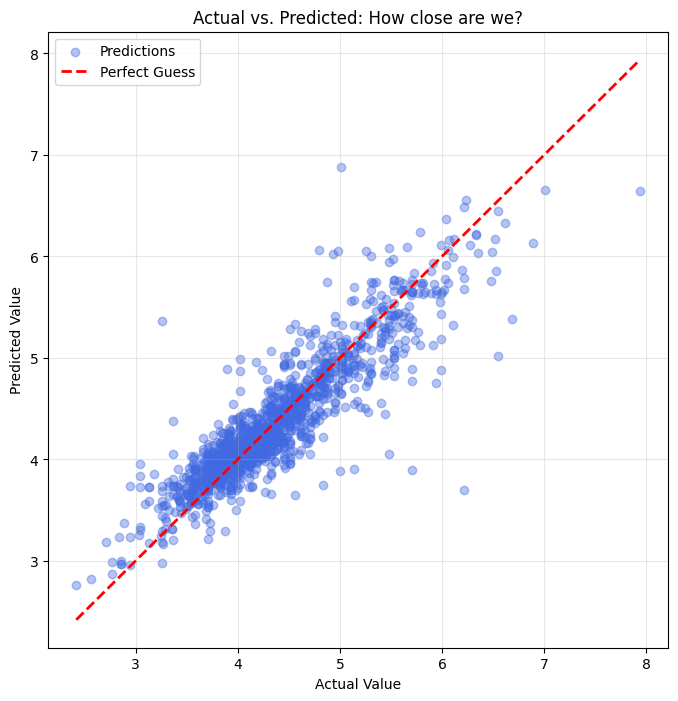

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8)) 

plt.scatter(y_test, y_pred, alpha=0.4, color='royalblue', label='Predictions')

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Perfect Guess')

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs. Predicted: How close are we?")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

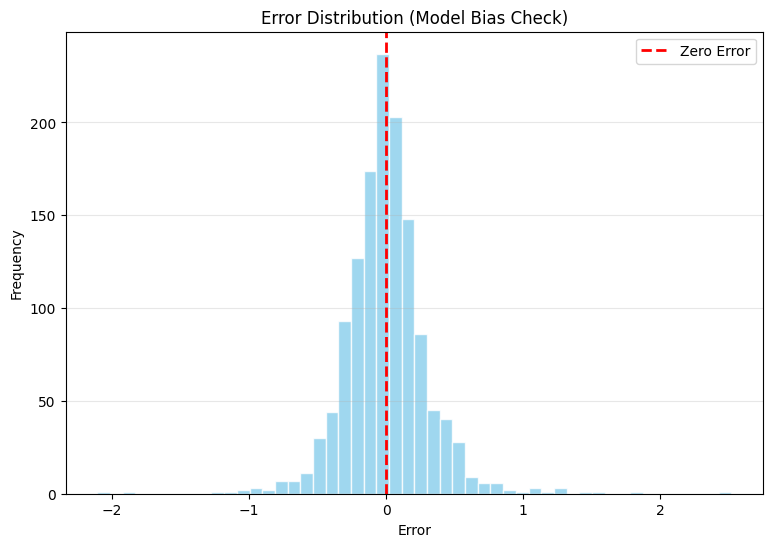

In [13]:
import matplotlib.pyplot as plt

errors = y_test - y_pred.reshape(-1)

plt.figure(figsize=(9, 6))

plt.hist(errors, bins=50, color='skyblue', edgecolor='white', alpha=0.8)

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

# 4. Labels
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Model Bias Check)")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()